# 05 Error Analysis: Morphology-Based Test Patch Categorization

This notebook performs morphology-based subgroup analysis **without retraining any model**. It directly reads the trained model outputs stored under `outputs/unet/`, `outputs/deeplabv3plus/`, and `outputs/segformer/`, and then evaluates the three architectures on morphology-specific subsets of the full test split.

## Morphology-Based Test Patch Categorization
To analyze model sensitivity to different urban change geometries, we categorize test patches according to the morphology of the ground-truth change masks rather than model predictions. This design ensures that the comparison reflects architectural differences under the same training setting, instead of differences caused by model-specific outputs.

For each test patch, let the binary ground-truth mask be denoted as $M$. We compute the following morphology descriptors:

- **Change ratio** $r$: the proportion of changed pixels in the patch, $r = |M| / (H \times W)$
- **Number of connected components** $n_c$: the number of connected change regions in the mask
- **Largest component ratio** $r_{\max}$: the area of the largest connected component divided by the total changed area
- **Elongation** $e$: a simple geometry descriptor derived from the bounding box of the largest component
- **Boundary complexity** $b$: an approximate perimeter-to-area style descriptor

These descriptors are then used to assign each patch into one of four categories:
- `large_scale_contiguous`
- `fragmented_or_linear`
- `complex_boundary`
- `other`


In [11]:
# ---------------------------------------------------------
# Project path setup
# ---------------------------------------------------------
import math
import sys
import random
from collections import deque
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

# Detect whether the notebook is running in Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    default_project_root = Path('/content/drive/MyDrive/DSAN6600-final-project')
else:
    default_project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()

sys.path.append(str(default_project_root))

try:
    from src.plot_utils import set_plot_style
    set_plot_style()
except Exception:
    pass

# ---------------------------------------------------------
# Load YAML config
# ---------------------------------------------------------
config_path = default_project_root / "configs" / "error_analysis.yaml"

with open(config_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

project_root = Path(config.get("project_root", str(default_project_root)))
data_root = Path(config["data_root"])
test_dir = data_root / config["test_split"]
time1_dir = test_dir / "time1"
time2_dir = test_dir / "time2"
label_dir = test_dir / "label"

analysis_dir = project_root / config["analysis_output_dir"]
analysis_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", project_root)
print("Data root:", data_root)
print("Test dir:", test_dir)
print("Analysis dir:", analysis_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/DSAN6600-final-project
Data root: subset_data
Test dir: subset_data/test
Analysis dir: /content/drive/MyDrive/DSAN6600-final-project/outputs/error_analysis


## Full Test Split

This notebook directly reads the full `test` folder from the dataset and does **not** load any subset TXT file.
This keeps the error analysis aligned with the actual exported test predictions stored by the model notebooks.


In [12]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def load_rgb(path, image_size=256):
    img = Image.open(path).convert("RGB").resize((image_size, image_size), Image.Resampling.BILINEAR)
    return np.asarray(img, dtype=np.float32) / 255.0


def load_mask(path, image_size=256):
    mask = Image.open(path).convert("L").resize((image_size, image_size), Image.Resampling.NEAREST)
    return (np.asarray(mask, dtype=np.uint8) > 0).astype(np.uint8)


def discover_test_ids(label_folder, time1_folder, time2_folder):
    label_ids = {p.stem for p in label_folder.glob("*.png")}
    time1_ids = {p.stem for p in time1_folder.glob("*.png")}
    time2_ids = {p.stem for p in time2_folder.glob("*.png")}
    shared_ids = sorted(label_ids & time1_ids & time2_ids)
    return shared_ids


set_seed(config.get("seed", 42))
base_image_size = config.get("image_size", 256)
test_ids = discover_test_ids(label_dir, time1_dir, time2_dir)

if not test_ids:
    raise FileNotFoundError(f"No shared PNG sample IDs found under: {test_dir}")

print("Number of discovered test patches:", len(test_ids))
print("First 5 sample IDs:", test_ids[:5])


Number of discovered test patches: 500
First 5 sample IDs: ['00006', '00021', '00066', '00067', '00077']


## Compute Morphology Descriptors from Ground-Truth Masks


In [13]:
NEIGHBORS_8 = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def connected_components(binary_mask):
    h, w = binary_mask.shape
    visited = np.zeros_like(binary_mask, dtype=bool)
    components = []

    for row in range(h):
        for col in range(w):
            if binary_mask[row, col] == 0 or visited[row, col]:
                continue

            queue = deque([(row, col)])
            visited[row, col] = True
            coords = []

            while queue:
                r, c = queue.popleft()
                coords.append((r, c))

                for dr, dc in NEIGHBORS_8:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < h and 0 <= nc < w and binary_mask[nr, nc] == 1 and not visited[nr, nc]:
                        visited[nr, nc] = True
                        queue.append((nr, nc))

            components.append(np.array(coords, dtype=np.int32))

    return components


def component_mask(shape, coords):
    comp = np.zeros(shape, dtype=np.uint8)
    comp[coords[:, 0], coords[:, 1]] = 1
    return comp


def approximate_perimeter(binary_component):
    h, w = binary_component.shape
    perimeter = 0
    rows, cols = np.where(binary_component == 1)
    for r, c in zip(rows, cols):
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w or binary_component[nr, nc] == 0:
                perimeter += 1
    return float(perimeter)


def compute_elongation(coords):
    if len(coords) < 3:
        return 1.0

    xy = coords.astype(np.float32)
    centered = xy - xy.mean(axis=0, keepdims=True)
    cov = np.cov(centered.T)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.clip(np.sort(eigvals), 1e-8, None)
    return float(np.sqrt(eigvals[-1] / eigvals[0]))


def describe_mask(binary_mask):
    total_pixels = binary_mask.size
    changed_pixels = int(binary_mask.sum())

    if changed_pixels == 0:
        return {
            "change_ratio": 0.0,
            "num_components": 0,
            "largest_component_ratio": 0.0,
            "elongation": 1.0,
            "boundary_complexity": 0.0,
        }

    components = connected_components(binary_mask)
    component_areas = [len(coords) for coords in components]
    largest_idx = int(np.argmax(component_areas))
    largest_coords = components[largest_idx]
    largest_area = float(component_areas[largest_idx])

    largest_mask = component_mask(binary_mask.shape, largest_coords)
    perimeter = approximate_perimeter(largest_mask)
    elongation = compute_elongation(largest_coords)
    boundary_complexity = float((perimeter ** 2) / (4 * math.pi * max(largest_area, 1.0)))

    return {
        "change_ratio": changed_pixels / total_pixels,
        "num_components": len(components),
        "largest_component_ratio": largest_area / changed_pixels,
        "elongation": elongation,
        "boundary_complexity": boundary_complexity,
    }


records = []
for sample_id in test_ids:
    mask = load_mask(data_root / "test" / "label" / f"{sample_id}.png", image_size=base_image_size)
    descriptors = describe_mask(mask)
    records.append({"sample_id": sample_id, **descriptors})

morph_df = pd.DataFrame(records).sort_values("sample_id").reset_index(drop=True)
morph_df.head()


,sample_id,change_ratio,num_components,largest_component_ratio,elongation,boundary_complexity
0,00006,0.141693,1,1.000000,1.818741,1.704634
1,00021,0.210266,1,1.000000,1.586432,1.708987
2,00066,0.123550,3,0.490923,3.996169,2.537190
3,00067,0.075043,2,0.589874,1.721117,2.403399
4,00077,0.164673,1,1.000000,1.502056,2.566801


In [14]:
quantiles = {
    "change_ratio_q25": morph_df["change_ratio"].quantile(0.25),
    "change_ratio_q75": morph_df["change_ratio"].quantile(0.75),
    "num_components_q50": morph_df["num_components"].quantile(0.50),
    "num_components_q75": morph_df["num_components"].quantile(0.75),
    "elongation_q75": morph_df["elongation"].quantile(0.75),
    "boundary_complexity_q75": morph_df["boundary_complexity"].quantile(0.75),
}

quantile_df = pd.DataFrame([{"metric": k, "value": v} for k, v in quantiles.items()])
quantile_df.to_csv(analysis_dir / "morphology_quantiles.csv", index=False)
quantile_df


,metric,value
0,change_ratio_q25,0.055080
1,change_ratio_q75,0.316921
2,num_components_q50,1.000000
3,num_components_q75,2.000000
4,elongation_q75,2.610138
5,boundary_complexity_q75,2.980145


## Assign Morphology Categories


In [15]:
def assign_category(row, q):
    is_large = (
        row["change_ratio"] >= q["change_ratio_q75"]
        and row["num_components"] <= q["num_components_q50"]
        and row["largest_component_ratio"] >= 0.70
    )

    is_fragmented_or_linear = (
        row["num_components"] >= q["num_components_q75"]
        or row["elongation"] >= q["elongation_q75"]
    )

    is_complex = (
        row["boundary_complexity"] >= q["boundary_complexity_q75"]
        and row["change_ratio"] >= q["change_ratio_q25"]
    )

    if is_large:
        return "large_scale_contiguous"
    if is_fragmented_or_linear:
        return "fragmented_or_linear"
    if is_complex:
        return "complex_boundary"
    return "other"


morph_df["category"] = morph_df.apply(assign_category, axis=1, q=quantiles)
category_counts = morph_df["category"].value_counts().rename_axis("category").reset_index(name="num_patches")

morph_df.to_csv(analysis_dir / "test_patch_morphology.csv", index=False)
category_counts.to_csv(analysis_dir / "category_counts.csv", index=False)

category_counts


,category,num_patches
0,fragmented_or_linear,235
1,other,149
2,large_scale_contiguous,96
3,complex_boundary,20


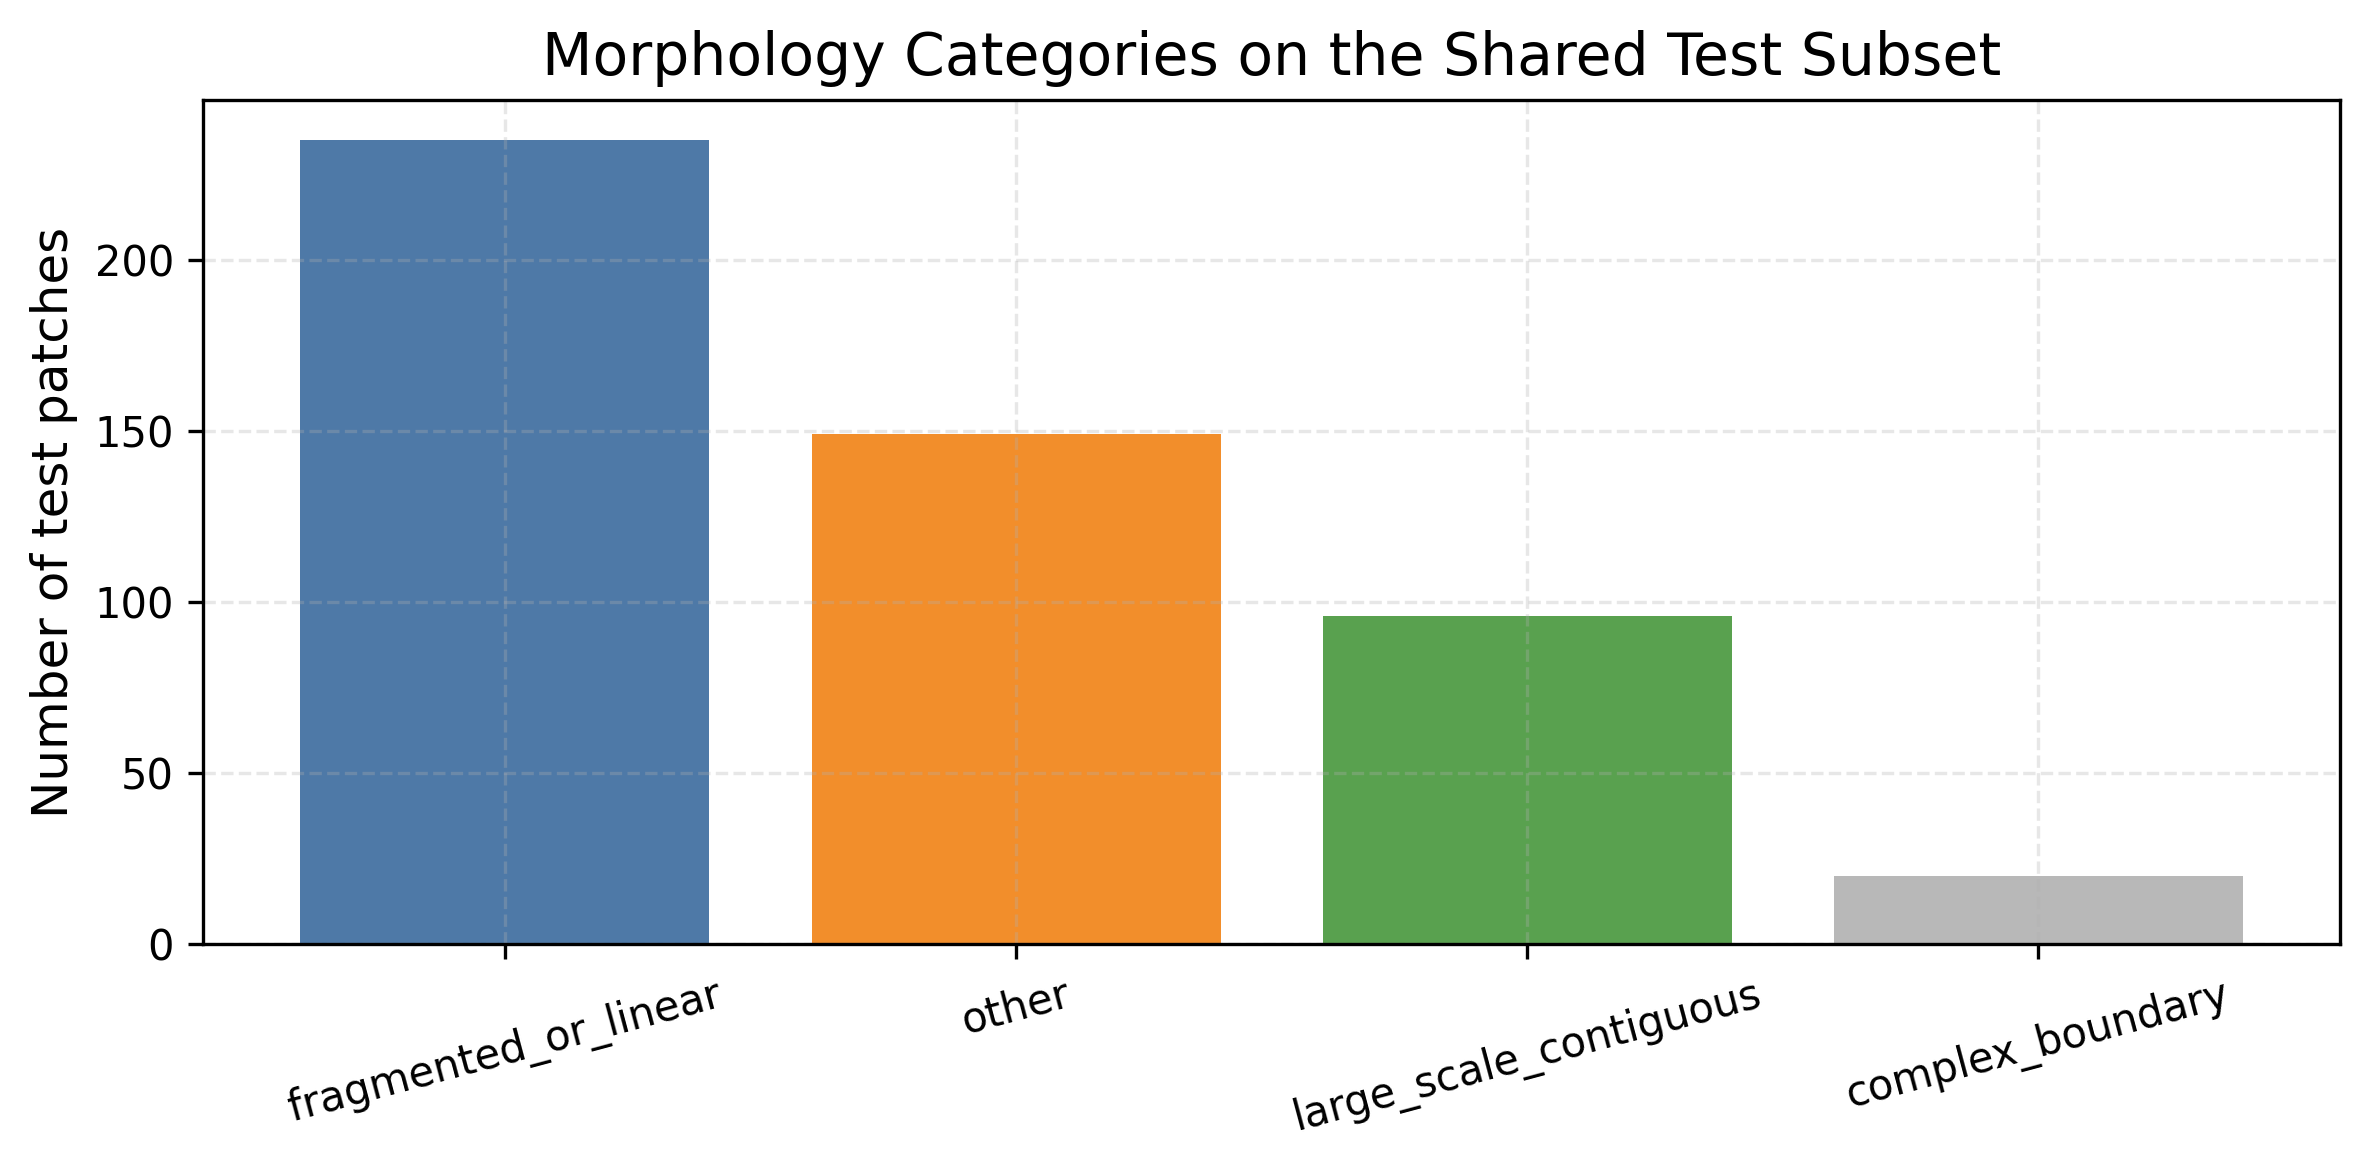

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(category_counts["category"], category_counts["num_patches"], color=["#4E79A7", "#F28E2B", "#59A14F", "#B8B8B8"])
plt.ylabel("Number of test patches")
plt.title("Morphology Categories on the Shared Test Subset")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Select Representative Patches for Qualitative Analysis


In [17]:
ranking_columns = {
    "large_scale_contiguous": ["change_ratio", "largest_component_ratio"],
    "fragmented_or_linear": ["num_components", "elongation"],
    "complex_boundary": ["boundary_complexity", "change_ratio"],
}

representatives = []
for category, cols in ranking_columns.items():
    subset = morph_df[morph_df["category"] == category].copy()
    if subset.empty:
        continue
    subset = subset.sort_values(cols, ascending=[False] * len(cols)).head(5)
    representatives.append(subset)

representative_df = pd.concat(representatives, ignore_index=True) if representatives else pd.DataFrame()
representative_df.to_csv(analysis_dir / "representative_patches.csv", index=False)
representative_df[["sample_id", "category", "change_ratio", "num_components", "elongation", "boundary_complexity"]]


,sample_id,category,change_ratio,num_components,elongation,boundary_complexity
0,01233,large_scale_contiguous,1.000000,1,1.000000,1.273240
1,02236,large_scale_contiguous,1.000000,1,1.000000,1.273240
2,02383,large_scale_contiguous,1.000000,1,1.000000,1.273240
3,02685,large_scale_contiguous,1.000000,1,1.000000,1.273240
4,02698,large_scale_contiguous,1.000000,1,1.000000,1.273240
5,01016,fragmented_or_linear,0.279602,6,1.547923,1.836599
6,00663,fragmented_or_linear,0.119080,6,1.096290,1.661163
7,03007,fragmented_or_linear,0.421143,5,1.262836,4.339128
8,00563,fragmented_or_linear,0.126419,4,3.132940,2.366951
9,02044,fragmented_or_linear,0.205444,4,2.016640,2.520466


## Load Trained Model Bundles from `outputs/`

This section does **not** retrain any model. It only reads the saved `config_used.yaml`, `best_*.pt`, and existing `test_predictions/` folders.


In [18]:
# U-Net definition
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, base_channels=64):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16)
        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8)
        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)
        self.out_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


# DeepLabV3+ definition
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, dilation=1):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=dilation, dilation=dilation, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )


class ASPPPooling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        size = x.shape[-2:]
        pooled = self.pool(x)
        pooled = self.conv(pooled)
        return F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256, atrous_rates=(6, 12, 18)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ),
            ASPPConv(in_channels, out_channels, atrous_rates[0]),
            ASPPConv(in_channels, out_channels, atrous_rates[1]),
            ASPPConv(in_channels, out_channels, atrous_rates[2]),
            ASPPPooling(in_channels, out_channels),
        ])
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * len(self.branches), out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        feats = [branch(x) for branch in self.branches]
        return self.project(torch.cat(feats, dim=1))


class SimpleBackbone(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()
        self.stage1 = nn.Sequential(ConvBNReLU(in_channels, 64, stride=2), ConvBNReLU(64, 64))
        self.stage2 = nn.Sequential(ConvBNReLU(64, 128, stride=2), ConvBNReLU(128, 128))
        self.stage3 = nn.Sequential(ConvBNReLU(128, 256, stride=2), ConvBNReLU(256, 256))
        self.stage4 = nn.Sequential(ConvBNReLU(256, 512, stride=2), ConvBNReLU(512, 512))

    def forward(self, x):
        x = self.stage1(x)
        low_level = self.stage2(x)
        x = self.stage3(low_level)
        high_level = self.stage4(x)
        return low_level, high_level


class DeepLabV3Plus(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        self.backbone = SimpleBackbone(in_channels=in_channels)
        self.aspp = ASPP(in_channels=512, out_channels=256)
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(128, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            DepthwiseSeparableConv(256 + 48, 256),
            DepthwiseSeparableConv(256, 256),
        )
        self.classifier = nn.Conv2d(256, out_channels, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]
        low_level, high_level = self.backbone(x)
        x = self.aspp(high_level)
        x = F.interpolate(x, size=low_level.shape[-2:], mode="bilinear", align_corners=False)
        low_level = self.low_level_proj(low_level)
        x = torch.cat([x, low_level], dim=1)
        x = self.decoder(x)
        logits = self.classifier(x)
        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


class SegFormerBinary(nn.Module):
    def __init__(self, in_channels=6, out_channels=1):
        super().__init__()
        from transformers import SegformerConfig, SegformerForSemanticSegmentation

        segformer_config = SegformerConfig(
            num_channels=in_channels,
            num_labels=out_channels,
            hidden_sizes=[32, 64, 160, 256],
            depths=[2, 2, 2, 2],
            decoder_hidden_size=256,
            reshape_last_stage=True,
        )
        self.model = SegformerForSemanticSegmentation(segformer_config)

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        logits = outputs.logits
        logits = F.interpolate(logits, size=x.shape[-2:], mode="nearest")
        return logits.contiguous()


In [19]:
MODEL_REGISTRY = {
    "unet": {
        "display_name": "U-Net",
        "builder": lambda config: UNet(
            in_channels=config["input_channels"],
            out_channels=config["num_classes"],
        ),
        "output_dir": project_root / config["model_output_roots"]["unet"],
    },
    "deeplabv3plus": {
        "display_name": "DeepLabV3+",
        "builder": lambda config: DeepLabV3Plus(
            in_channels=config["input_channels"],
            out_channels=config["num_classes"],
        ),
        "output_dir": project_root / config["model_output_roots"]["deeplabv3plus"],
    },
    "segformer": {
        "display_name": "SegFormer",
        "builder": lambda config: SegFormerBinary(
            in_channels=config["input_channels"],
            out_channels=config["num_classes"],
        ),
        "output_dir": project_root / config["model_output_roots"]["segformer"],
    },
}


def select_device(config, model_name):
    if model_name == "segformer" and config.get("force_segformer_cpu", False):
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def load_model_bundle(model_name):
    spec = MODEL_REGISTRY[model_name]
    output_dir = spec["output_dir"]
    config_path = output_dir / "config_used.yaml"
    if not config_path.exists():
        return {
            "model_name": model_name,
            "display_name": spec["display_name"],
            "status": "missing_config",
            "output_dir": output_dir,
        }

    with open(config_path, "r", encoding="utf-8") as f:
        model_config = yaml.safe_load(f)

    checkpoint_path = output_dir / model_config["model_save_name"]
    prediction_dir = output_dir / "test_predictions"
    device = select_device(model_config, model_name)

    bundle = {
        "model_name": model_name,
        "display_name": spec["display_name"],
        "config": model_config,
        "output_dir": output_dir,
        "checkpoint_path": checkpoint_path,
        "prediction_dir": prediction_dir,
        "device": str(device),
        "status": None,
        "model": None,
    }

    if checkpoint_path.exists():
        try:
            model = spec["builder"](model_config).to(device)
            state_dict = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(state_dict)
            model.eval()
            bundle["model"] = model
            bundle["status"] = "checkpoint_loaded"
            bundle["device_obj"] = device
            return bundle
        except Exception as exc:
            bundle["status"] = f"checkpoint_error: {exc}"
            bundle["device_obj"] = device
            return bundle

    if prediction_dir.exists():
        bundle["status"] = "saved_predictions_only"
        bundle["device_obj"] = device
        return bundle

    bundle["status"] = "missing_checkpoint_and_predictions"
    bundle["device_obj"] = device
    return bundle


model_bundles = {name: load_model_bundle(name) for name in MODEL_REGISTRY}
status_df = pd.DataFrame([
    {
        "model": name,
        "display_name": bundle["display_name"],
        "status": bundle["status"],
        "device": bundle.get("device"),
        "checkpoint": str(bundle.get("checkpoint_path", "")),
    }
    for name, bundle in model_bundles.items()
])
status_df.to_csv(analysis_dir / "model_loading_status.csv", index=False)
status_df


,model,display_name,status,device,checkpoint
0,unet,U-Net,checkpoint_loaded,cuda,/content/drive/MyDrive/DSAN6600-final-project/...
1,deeplabv3plus,DeepLabV3+,checkpoint_loaded,cuda,/content/drive/MyDrive/DSAN6600-final-project/...
2,segformer,SegFormer,checkpoint_loaded,cuda,/content/drive/MyDrive/DSAN6600-final-project/...


## Run Inference from Saved Checkpoints (or Fallback to Saved Predictions)

For each model, inference is performed from the saved checkpoint when available. If a checkpoint is missing but `test_predictions/` exists, the notebook falls back to those exported predictions and reports the actual sample coverage.


In [20]:
def prepare_input_tensor(sample_id, image_size=256):
    time1 = load_rgb(time1_dir / f"{sample_id}.png", image_size=image_size)
    time2 = load_rgb(time2_dir / f"{sample_id}.png", image_size=image_size)
    image = np.concatenate([time1, time2], axis=-1)
    tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float()
    return tensor


def load_saved_prediction(prediction_dir, sample_id, image_size=256):
    pred_path = prediction_dir / f"{sample_id}_pred.png"
    if not pred_path.exists():
        return None
    pred = Image.open(pred_path).convert("L").resize((image_size, image_size), Image.Resampling.NEAREST)
    pred = (np.asarray(pred, dtype=np.uint8) > 0).astype(np.uint8)
    return pred


def predict_mask(bundle, sample_id):
    model_config = bundle["config"]
    image_size = model_config.get("image_size", 256)

    if bundle["model"] is not None:
        device = bundle["device_obj"]
        x = prepare_input_tensor(sample_id, image_size=image_size).to(device)
        with torch.no_grad():
            logits = bundle["model"](x)
            probs = torch.sigmoid(logits)
            pred = (probs >= model_config.get("threshold", 0.5)).float()
        return pred.squeeze().detach().cpu().numpy().astype(np.uint8)

    if bundle["prediction_dir"].exists():
        return load_saved_prediction(bundle["prediction_dir"], sample_id, image_size=image_size)

    return None


def compute_confusion(pred, target):
    pred = pred.reshape(-1)
    target = target.reshape(-1)
    tp = int(((pred == 1) & (target == 1)).sum())
    fp = int(((pred == 1) & (target == 0)).sum())
    fn = int(((pred == 0) & (target == 1)).sum())
    tn = int(((pred == 0) & (target == 0)).sum())
    return tp, fp, fn, tn


def compute_metrics_from_counts(tp, fp, fn, tn, eps=1e-8):
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)
    return precision, recall, f1, iou


In [21]:
sample_predictions = {}
coverage_rows = []

for model_name, bundle in model_bundles.items():
    model_preds = {}
    for sample_id in test_ids:
        pred = predict_mask(bundle, sample_id)
        if pred is not None:
            model_preds[sample_id] = pred
    sample_predictions[model_name] = model_preds
    coverage_rows.append({
        "model": model_name,
        "display_name": bundle["display_name"],
        "status": bundle["status"],
        "predicted_samples": len(model_preds),
        "total_test_patches": len(test_ids),
    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(analysis_dir / "prediction_coverage.csv", index=False)
coverage_df


,model,display_name,status,predicted_samples,total_test_patches
0,unet,U-Net,checkpoint_loaded,500,500
1,deeplabv3plus,DeepLabV3+,checkpoint_loaded,500,500
2,segformer,SegFormer,checkpoint_loaded,500,500


## Category-Level Metrics Across Morphology Groups


In [22]:
metric_rows = []

for model_name, preds_by_id in sample_predictions.items():
    bundle = model_bundles[model_name]
    image_size = bundle.get("config", {}).get("image_size", base_image_size)

    for category in ["large_scale_contiguous", "fragmented_or_linear", "complex_boundary", "other"]:
        subset_ids = morph_df.loc[morph_df["category"] == category, "sample_id"].tolist()
        total_tp = total_fp = total_fn = total_tn = 0
        used_samples = 0

        for sample_id in subset_ids:
            pred = preds_by_id.get(sample_id)
            if pred is None:
                continue
            target = load_mask(label_dir / f"{sample_id}.png", image_size=image_size)
            tp, fp, fn, tn = compute_confusion(pred, target)
            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn
            used_samples += 1

        if used_samples == 0:
            metric_rows.append({
                "model": model_name,
                "display_name": bundle["display_name"],
                "category": category,
                "used_samples": 0,
                "precision": np.nan,
                "recall": np.nan,
                "f1": np.nan,
                "iou": np.nan,
            })
            continue

        precision, recall, f1, iou = compute_metrics_from_counts(total_tp, total_fp, total_fn, total_tn)
        metric_rows.append({
            "model": model_name,
            "display_name": bundle["display_name"],
            "category": category,
            "used_samples": used_samples,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "iou": iou,
        })

category_metrics_df = pd.DataFrame(metric_rows)
category_metrics_df.to_csv(analysis_dir / "category_metrics.csv", index=False)
category_metrics_df


,model,display_name,category,used_samples,precision,recall,f1,iou
0,unet,U-Net,large_scale_contiguous,96,0.897910,0.812038,0.852818,0.743402
1,unet,U-Net,fragmented_or_linear,235,0.629685,0.655253,0.642215,0.472987
2,unet,U-Net,complex_boundary,20,0.471340,0.605556,0.530084,0.360622
3,unet,U-Net,other,149,0.610941,0.613985,0.612459,0.441399
4,deeplabv3plus,DeepLabV3+,large_scale_contiguous,96,0.875876,0.857411,0.866545,0.764517
5,deeplabv3plus,DeepLabV3+,fragmented_or_linear,235,0.585965,0.701715,0.638638,0.469117
6,deeplabv3plus,DeepLabV3+,complex_boundary,20,0.538944,0.739250,0.623402,0.452857
7,deeplabv3plus,DeepLabV3+,other,149,0.593760,0.677212,0.632746,0.462786
8,segformer,SegFormer,large_scale_contiguous,96,0.899695,0.732761,0.807693,0.677420
9,segformer,SegFormer,fragmented_or_linear,235,0.596122,0.510864,0.550210,0.379510


In [23]:
pivot_iou = category_metrics_df.pivot(index="display_name", columns="category", values="iou")
pivot_f1 = category_metrics_df.pivot(index="display_name", columns="category", values="f1")

print("IoU by morphology category")
display(pivot_iou)
print("F1 by morphology category")
display(pivot_f1)


IoU by morphology category


category,complex_boundary,fragmented_or_linear,large_scale_contiguous,other
display_name,,,,
DeepLabV3+,0.452857,0.469117,0.764517,0.462786
SegFormer,0.371510,0.379510,0.677420,0.343396
U-Net,0.360622,0.472987,0.743402,0.441399


F1 by morphology category


category,complex_boundary,fragmented_or_linear,large_scale_contiguous,other
display_name,,,,
DeepLabV3+,0.623402,0.638638,0.866545,0.632746
SegFormer,0.541753,0.550210,0.807693,0.511236
U-Net,0.530084,0.642215,0.852818,0.612459


## Representative Patch Visualization


In [24]:
DISPLAY_MODELS = [name for name, preds in sample_predictions.items() if len(preds) > 0]
print("Models with available predictions:", DISPLAY_MODELS)


Models with available predictions: ['unet', 'deeplabv3plus', 'segformer']


In [25]:
def show_patch_comparison(sample_id):
    before = load_rgb(time1_dir / f"{sample_id}.png", image_size=base_image_size)
    after = load_rgb(time2_dir / f"{sample_id}.png", image_size=base_image_size)
    target = load_mask(label_dir / f"{sample_id}.png", image_size=base_image_size)

    columns = 3 + len(DISPLAY_MODELS)
    fig, axes = plt.subplots(1, columns, figsize=(4 * columns, 4))

    axes[0].imshow(before)
    axes[0].set_title(f"{sample_id} | Time 1")
    axes[0].axis("off")

    axes[1].imshow(after)
    axes[1].set_title("Time 2")
    axes[1].axis("off")

    axes[2].imshow(target, cmap="gray")
    axes[2].set_title("Ground Truth")
    axes[2].axis("off")

    for idx, model_name in enumerate(DISPLAY_MODELS, start=3):
        pred = sample_predictions[model_name].get(sample_id)
        if pred is None:
            pred = np.zeros_like(target)
        axes[idx].imshow(pred, cmap="gray")
        axes[idx].set_title(model_bundles[model_name]["display_name"])
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


for category in ["large_scale_contiguous", "fragmented_or_linear", "complex_boundary"]:
    print(f"\nCategory: {category}")
    category_ids = representative_df.loc[representative_df["category"] == category, "sample_id"].tolist()[:3]
    for sample_id in category_ids:
        show_patch_comparison(sample_id)


Output hidden; open in https://colab.research.google.com to view.

## Exported Analysis Files


In [26]:
print("Analysis outputs:")
for path in sorted(analysis_dir.glob("*.csv")):
    print(path.relative_to(project_root))


Analysis outputs:
outputs/error_analysis/category_counts.csv
outputs/error_analysis/category_metrics.csv
outputs/error_analysis/model_loading_status.csv
outputs/error_analysis/morphology_quantiles.csv
outputs/error_analysis/prediction_coverage.csv
outputs/error_analysis/representative_patches.csv
outputs/error_analysis/test_patch_morphology.csv
